<a href="https://colab.research.google.com/github/MDEmon027/0192nd_assignmentOfPH/blob/main/adaptiveML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt

--2026-04-19 14:57:14--  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain+.txt’

KDDTrain+.txt       100%[===================>]  18.22M  --.-KB/s    in 0.1s    

2026-04-19 14:57:14 (172 MB/s) - ‘KDDTrain+.txt’ saved [19109424/19109424]



In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.tree import DecisionTreeClassifier

In [3]:
cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
        "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
        "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
        "is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
        "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
        "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
        "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
        "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]

df = pd.read_csv("KDDTrain+.txt", names=cols)

In [5]:
# Convert label → binary
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# 🔥 ALL categorical columns detect automatically
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical columns:", categorical_cols)

# Encode all categorical columns
from sklearn.preprocessing import LabelEncoder

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Now separate
X = df.drop('label', axis=1)
y = df['label'].values

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

Categorical columns: Index(['duration', 'dst_host_srv_rerror_rate'], dtype='object')


In [6]:
stream_size = 50000
X_stream = X[:stream_size]
y_stream = y[:stream_size]

In [7]:
def hybrid_resample(X, y):
    imbalance_ratio = np.sum(y==0) / np.sum(y==1)

    if imbalance_ratio > 5:
        sm = SMOTE(sampling_strategy=0.5)
        X_res, y_res = sm.fit_resample(X, y)

        ada = ADASYN(sampling_strategy=0.8)
        X_res, y_res = ada.fit_resample(X_res, y_res)
    else:
        X_res, y_res = X, y

    return X_res, y_res

In [8]:
model = DecisionTreeClassifier()
window_size = 1000

f1_scores = []

for i in range(window_size, len(X_stream), window_size):

    X_batch = X_stream[i-window_size:i]
    y_batch = y_stream[i-window_size:i]

    # Apply Hybrid Resampling
    X_res, y_res = hybrid_resample(X_batch, y_batch)

    # Train
    model.fit(X_res, y_res)

    # Test next batch (Prequential style)
    if i + window_size < len(X_stream):
        X_test = X_stream[i:i+window_size]
        y_test = y_stream[i:i+window_size]

        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)

        f1_scores.append(f1)

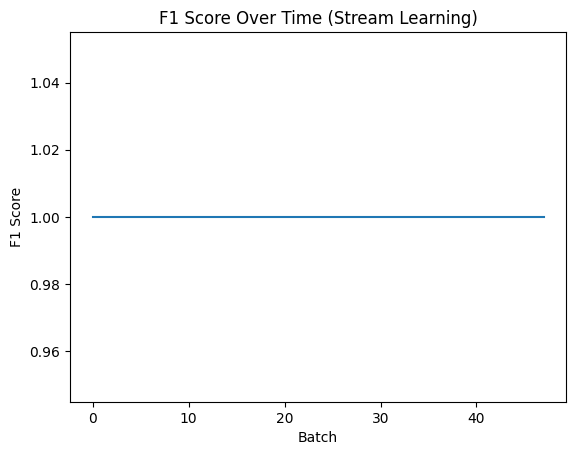

In [9]:
import matplotlib.pyplot as plt

plt.plot(f1_scores)
plt.title("F1 Score Over Time (Stream Learning)")
plt.xlabel("Batch")
plt.ylabel("F1 Score")
plt.show()

In [10]:
# simulate sudden drift
drift_point = 25000

X_stream[drift_point:] = np.roll(X_stream[drift_point:], shift=5, axis=1)

In [11]:
import pandas as pd

# Create table
results_df = pd.DataFrame({
    "Batch": list(range(1, len(f1_scores)+1)),
    "F1 Score": f1_scores
})

# Show first few rows
results_df.head()

,Batch,F1 Score
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


In [12]:
print(results_df)

    Batch  F1 Score
0       1       1.0
1       2       1.0
2       3       1.0
3       4       1.0
4       5       1.0
5       6       1.0
6       7       1.0
7       8       1.0
8       9       1.0
9      10       1.0
10     11       1.0
11     12       1.0
12     13       1.0
13     14       1.0
14     15       1.0
15     16       1.0
16     17       1.0
17     18       1.0
18     19       1.0
19     20       1.0
20     21       1.0
21     22       1.0
22     23       1.0
23     24       1.0
24     25       1.0
25     26       1.0
26     27       1.0
27     28       1.0
28     29       1.0
29     30       1.0
30     31       1.0
31     32       1.0
32     33       1.0
33     34       1.0
34     35       1.0
35     36       1.0
36     37       1.0
37     38       1.0
38     39       1.0
39     40       1.0
40     41       1.0
41     42       1.0
42     43       1.0
43     44       1.0
44     45       1.0
45     46       1.0
46     47       1.0
47     48       1.0


In [13]:
summary = pd.DataFrame({
    "Metric": ["Average F1", "Max F1", "Min F1"],
    "Value": [np.mean(f1_scores), np.max(f1_scores), np.min(f1_scores)]
})

print(summary)

       Metric  Value
0  Average F1    1.0
1      Max F1    1.0
2      Min F1    1.0


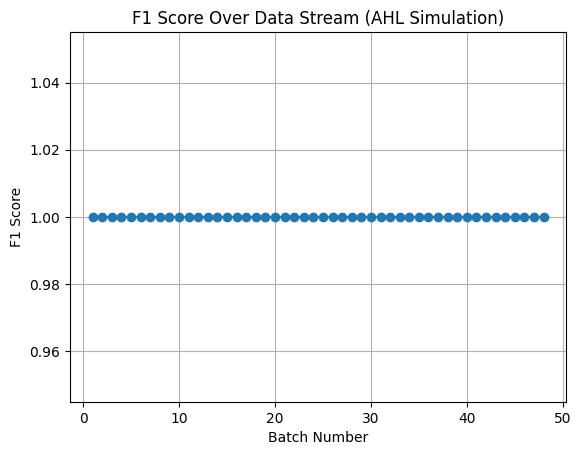

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(results_df["Batch"], results_df["F1 Score"], marker='o')

plt.title("F1 Score Over Data Stream (AHL Simulation)")
plt.xlabel("Batch Number")
plt.ylabel("F1 Score")

plt.grid()
plt.show()

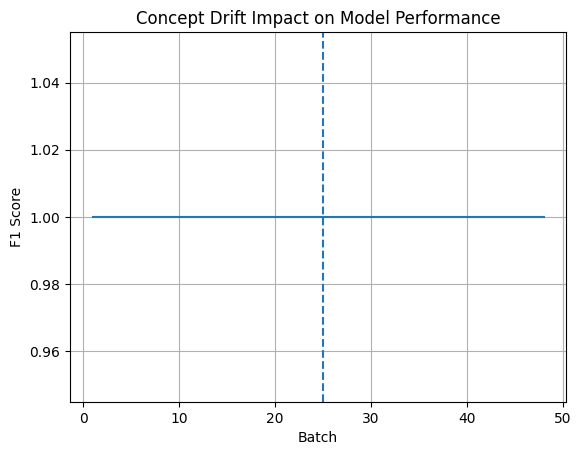

In [15]:
drift_batch = drift_point // window_size

plt.figure()
plt.plot(results_df["Batch"], results_df["F1 Score"])

plt.axvline(x=drift_batch, linestyle='--')  # Drift line

plt.title("Concept Drift Impact on Model Performance")
plt.xlabel("Batch")
plt.ylabel("F1 Score")

plt.grid()
plt.show()

=== RESULT TABLE ===
   Batch  F1 Score
0      1       1.0
1      2       1.0
2      3       1.0
3      4       1.0
4      5       1.0
5      6       1.0
6      7       1.0
7      8       1.0
8      9       1.0
9     10       1.0


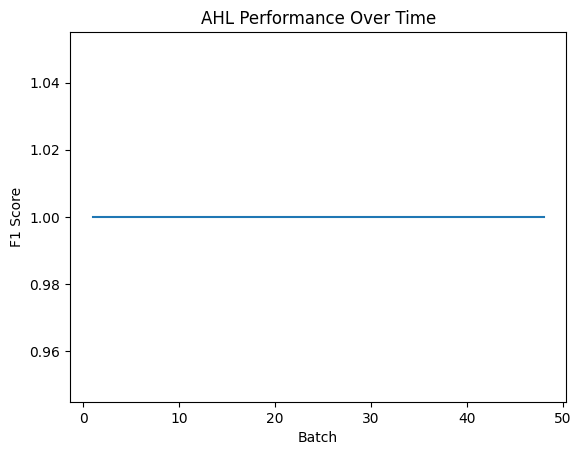

In [16]:
print("=== RESULT TABLE ===")
print(results_df.head(10))

plt.figure()
plt.plot(results_df["Batch"], results_df["F1 Score"])
plt.title("AHL Performance Over Time")
plt.xlabel("Batch")
plt.ylabel("F1 Score")
plt.show()